In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [16]:
df = pd.read_csv("Medical_appointment_data.csv")

df.head()

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0


In [17]:
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])

daily = (
    df.groupby('appointment_date_continuous')
      .size()
      .reset_index(name='Appointments')
)

daily.head()

,appointment_date_continuous,Appointments
0,2020-01-01,25
1,2020-01-02,33
2,2020-01-03,18
3,2020-01-04,16
4,2020-01-05,15


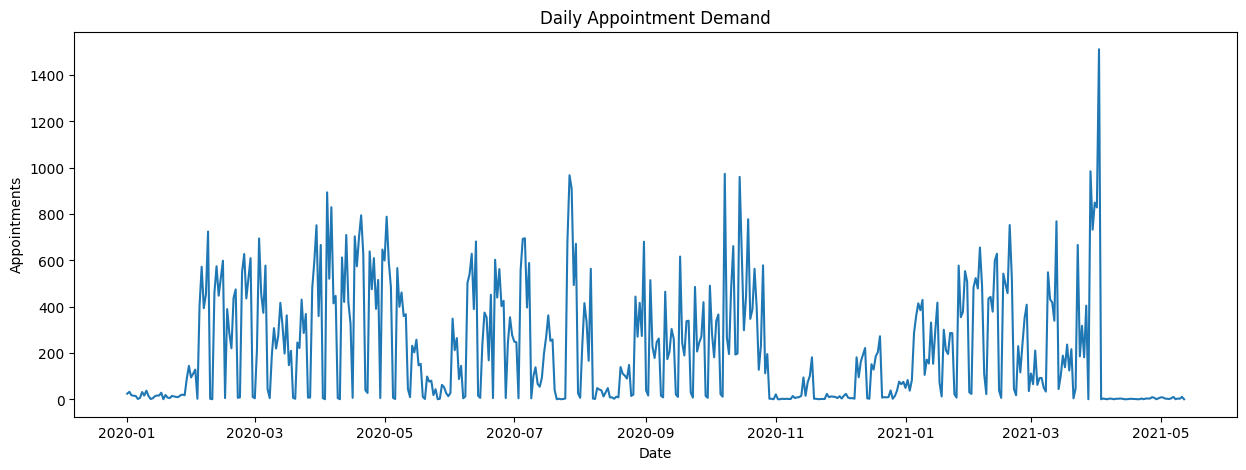

In [18]:
plt.figure(figsize=(15,5))

plt.plot(
    daily['appointment_date_continuous'],
    daily['Appointments']
)

plt.title("Daily Appointment Demand")
plt.xlabel("Date")
plt.ylabel("Appointments")

plt.show()

In [19]:
daily['Year'] = daily['appointment_date_continuous'].dt.year
daily['Month'] = daily['appointment_date_continuous'].dt.month
daily['Day'] = daily['appointment_date_continuous'].dt.day
daily['Weekday'] = daily['appointment_date_continuous'].dt.dayofweek
daily['WeekOfYear'] = daily['appointment_date_continuous'].dt.isocalendar().week.astype(int)
daily['Quarter'] = daily['appointment_date_continuous'].dt.quarter
daily['IsWeekend'] = daily['Weekday'].isin([5,6]).astype(int)

daily.head()

,appointment_date_continuous,Appointments,Year,Month,Day,Weekday,WeekOfYear,Quarter,IsWeekend
0,2020-01-01,25,2020,1,1,2,1,1,0
1,2020-01-02,33,2020,1,2,3,1,1,0
2,2020-01-03,18,2020,1,3,4,1,1,0
3,2020-01-04,16,2020,1,4,5,1,1,1
4,2020-01-05,15,2020,1,5,6,1,1,1


In [20]:
X = daily.drop(
    ['appointment_date_continuous','Appointments'],
    axis=1
)

y = daily['Appointments']

X.head()

,Year,Month,Day,Weekday,WeekOfYear,Quarter,IsWeekend
0,2020,1,1,2,1,1,0
1,2020,1,2,3,1,1,0
2,2020,1,3,4,1,1,0
3,2020,1,4,5,1,1,1
4,2020,1,5,6,1,1,1


In [21]:
split = int(len(daily) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape)
print(X_test.shape)

(398, 7)
(100, 7)


In [22]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_estimators=200
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    mape = np.mean(
        np.abs((y_test - pred) / y_test)
    ) * 100

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,RMSE,MAE,MAPE,R2
0,Linear Regression,285.139829,229.976126,4550.214195,-0.006790
1,Random Forest,358.474676,293.715100,7829.698747,-0.591256


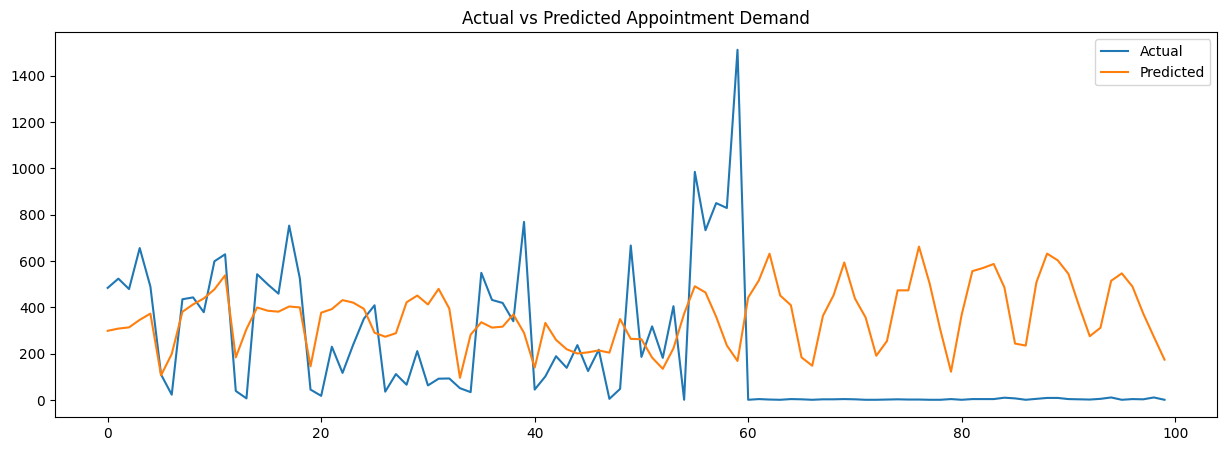

In [23]:
best_model = RandomForestRegressor(
    random_state=42,
    n_estimators=200
)

best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

plt.figure(figsize=(15,5))

plt.plot(y_test.values, label='Actual')
plt.plot(pred, label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Appointment Demand")

plt.show()

In [24]:
import joblib

joblib.dump(best_model, "demand_forecasting_model.pkl")

print("Demand Forecasting Model Saved Successfully")

Demand Forecasting Model Saved Successfully


Demand Forecasting Model Performance
MAE        : 293.72
RMSE       : 358.47
MAPE       : 7829.70%
R2 Score   : -0.591


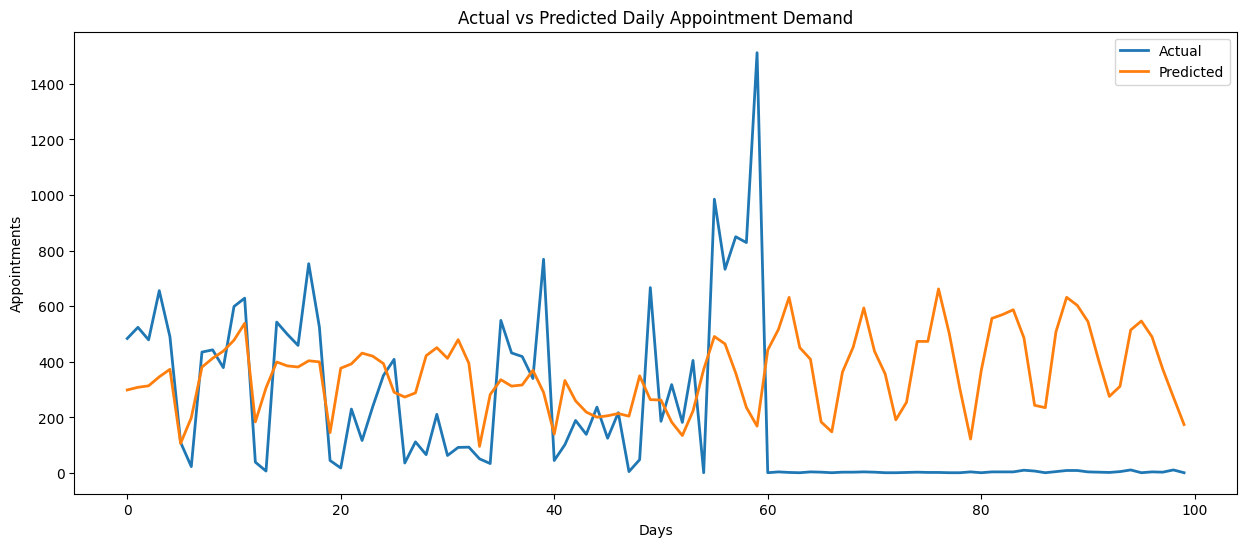


Top 10 Important Features


,Feature,Importance
4,WeekOfYear,0.406847
2,Day,0.249106
3,Weekday,0.212156
1,Month,0.062012
0,Year,0.035548
5,Quarter,0.018586
6,IsWeekend,0.015746


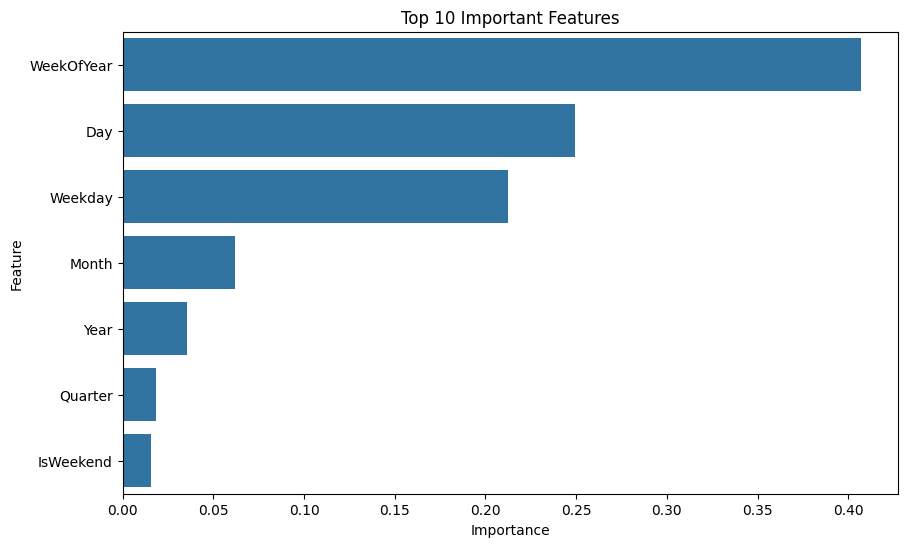


Model Saved Successfully as demand_forecasting_model.pkl


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# -------------------------------
# Predictions
# -------------------------------

pred = best_model.predict(X_test)

# -------------------------------
# Evaluation Metrics
# -------------------------------

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
r2 = r2_score(y_test, pred)

print("="*50)
print("Demand Forecasting Model Performance")
print("="*50)

print(f"MAE        : {mae:.2f}")
print(f"RMSE       : {rmse:.2f}")
print(f"MAPE       : {mape:.2f}%")
print(f"R2 Score   : {r2:.3f}")

# -------------------------------
# Actual vs Predicted Plot
# -------------------------------

plt.figure(figsize=(15,6))

plt.plot(y_test.values,
         label="Actual",
         linewidth=2)

plt.plot(pred,
         label="Predicted",
         linewidth=2)

plt.title("Actual vs Predicted Daily Appointment Demand")
plt.xlabel("Days")
plt.ylabel("Appointments")
plt.legend()
plt.show()

# -------------------------------
# Feature Importance
# -------------------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features")
display(importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

# -------------------------------
# Save Model
# -------------------------------

joblib.dump(best_model, "demand_forecasting_model.pkl")

print("\nModel Saved Successfully as demand_forecasting_model.pkl")